In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading dataset

In [2]:
data = pd.read_csv("car_price_regression_dataset.csv")

### Understanding the dataset

In [3]:
data.head()

,Brand,Fuel_Type,Transmission,Owner_Type,Year,Engine_CC,Mileage,Kilometers_Driven,Seats,Price_Lakhs
0,Volkswagen,Petrol,Manual,First,2015,1600.0,14.2,59330,5.0,8.26
1,Toyota,CNG,Manual,First,2015,1800.0,19.2,56707,7.0,11.73
2,Kia,Petrol,Manual,First,2017,1400.0,27.2,23689,5.0,13.24
3,Tata,Diesel,Manual,Second,2021,1800.0,11.7,34084,5.0,9.31
4,Volkswagen,Petrol,Manual,Second,2021,1400.0,16.2,45387,7.0,9.81


In [4]:
data.tail()

,Brand,Fuel_Type,Transmission,Owner_Type,Year,Engine_CC,Mileage,Kilometers_Driven,Seats,Price_Lakhs
495,Maruti,Petrol,Automatic,Second,2017,1400.0,21.3,104165,7.0,8.28
496,Volkswagen,Petrol,Manual,First,2016,800.0,21.5,60863,7.0,11.25
497,Volkswagen,Diesel,Manual,First,2014,800.0,11.0,87569,7.0,8.06
498,Nissan,Petrol,Manual,First,2020,1600.0,24.8,21351,6.0,11.72
499,Honda,Petrol,Manual,Second,2016,1600.0,16.0,140203,5.0,6.90


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              500 non-null    object 
 1   Fuel_Type          500 non-null    object 
 2   Transmission       500 non-null    object 
 3   Owner_Type         500 non-null    object 
 4   Year               500 non-null    int64  
 5   Engine_CC          495 non-null    float64
 6   Mileage            495 non-null    float64
 7   Kilometers_Driven  500 non-null    int64  
 8   Seats              495 non-null    float64
 9   Price_Lakhs        500 non-null    float64
dtypes: float64(4), int64(2), object(4)
memory usage: 39.2+ KB


In [6]:
data.describe()

,Year,Engine_CC,Mileage,Kilometers_Driven,Seats,Price_Lakhs
count,500.000000,495.000000,495.000000,500.000000,495.000000,500.00000
mean,2018.356000,1481.616162,18.286263,76157.828000,5.569697,9.87040
std,3.900216,449.342090,3.501777,41971.935032,0.947344,2.37085
min,2012.000000,800.000000,10.000000,5192.000000,4.000000,3.81000
25%,2015.000000,1200.000000,15.900000,39827.250000,5.000000,8.17750
50%,2018.000000,1400.000000,18.500000,77542.500000,5.000000,9.90000
75%,2022.000000,1800.000000,20.500000,113323.750000,7.000000,11.50750
max,2025.000000,2200.000000,28.000000,149989.000000,7.000000,17.28000


### Checking Missing Values

In [7]:
data.isnull().sum()

Brand                0
Fuel_Type            0
Transmission         0
Owner_Type           0
Year                 0
Engine_CC            5
Mileage              5
Kilometers_Driven    0
Seats                5
Price_Lakhs          0
dtype: int64

### Handling Missing Values 
Missing values in numerical columns handles using median imputation

In [8]:
data["Engine_CC"] = data["Engine_CC"].fillna(data["Engine_CC"].median())
data["Seats"] = data["Seats"].fillna(data["Seats"].median())

In [9]:
data["Mileage"] = data["Mileage"].fillna(data["Mileage"].median())

In [10]:
data.isnull().sum()

Brand                0
Fuel_Type            0
Transmission         0
Owner_Type           0
Year                 0
Engine_CC            0
Mileage              0
Kilometers_Driven    0
Seats                0
Price_Lakhs          0
dtype: int64

### Check duplicates

In [11]:
data.duplicated().sum()

np.int64(0)

### Feature Engineering
Created a new "Car_Age" feature from the "Year" column to represent the age of the car

In [12]:
data["Car_Age"] = 2026 - data["Year"]

In [13]:
data.head()

,Brand,Fuel_Type,Transmission,Owner_Type,Year,Engine_CC,Mileage,Kilometers_Driven,Seats,Price_Lakhs,Car_Age
0,Volkswagen,Petrol,Manual,First,2015,1600.0,14.2,59330,5.0,8.26,11
1,Toyota,CNG,Manual,First,2015,1800.0,19.2,56707,7.0,11.73,11
2,Kia,Petrol,Manual,First,2017,1400.0,27.2,23689,5.0,13.24,9
3,Tata,Diesel,Manual,Second,2021,1800.0,11.7,34084,5.0,9.31,5
4,Volkswagen,Petrol,Manual,Second,2021,1400.0,16.2,45387,7.0,9.81,5


### Exploratory Data Analysis

#### Univariate Analysis
Analyzed individual numerical and categorical variable to understand their distributions

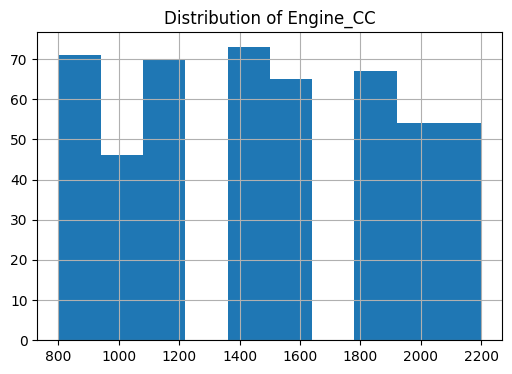

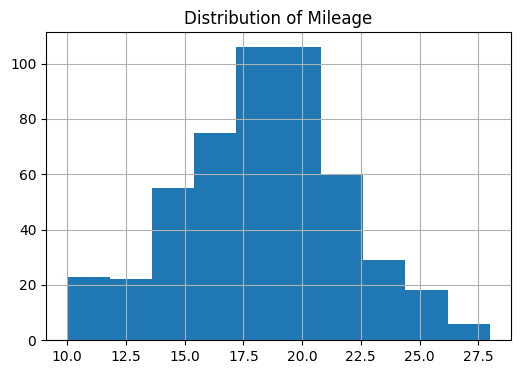

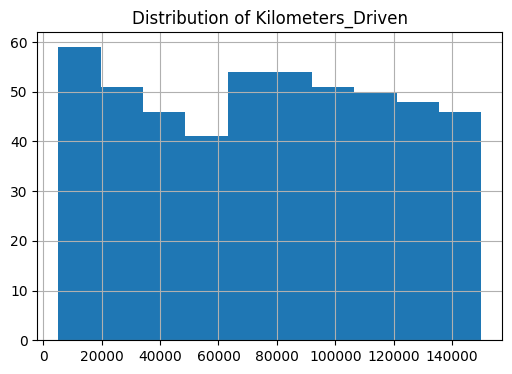

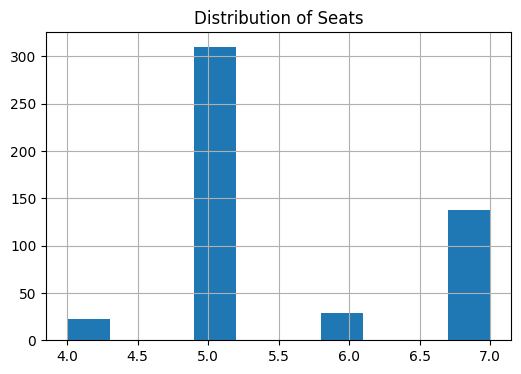

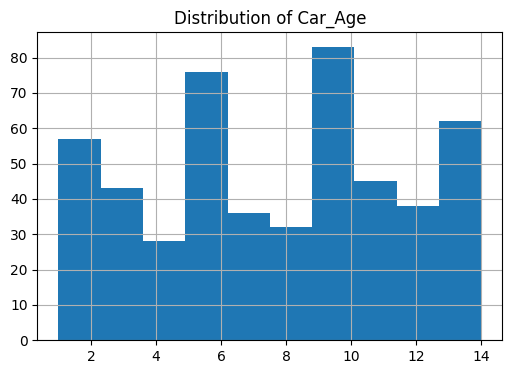

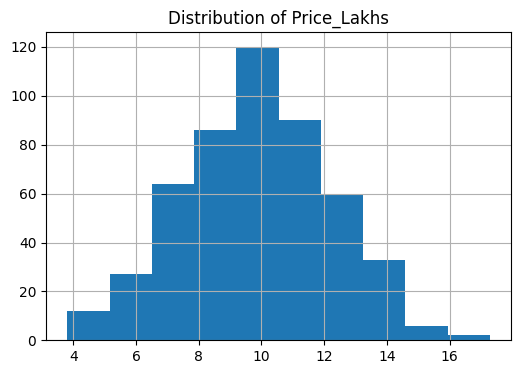

In [14]:
numerical_cols = ["Engine_CC","Mileage","Kilometers_Driven","Seats","Car_Age","Price_Lakhs"]

for col in numerical_cols:
    plt.figure(figsize = (6,4))
    data[col].hist()
    plt.title(f"Distribution of {col}")
    plt.show()

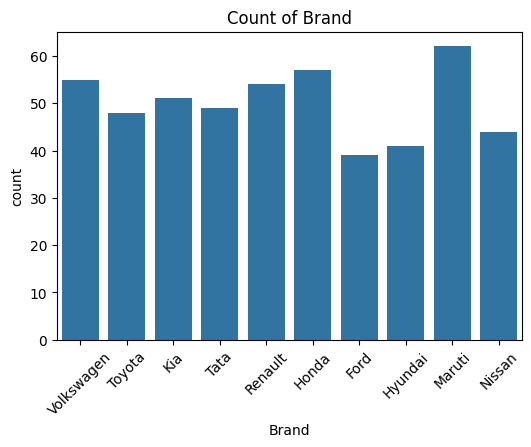

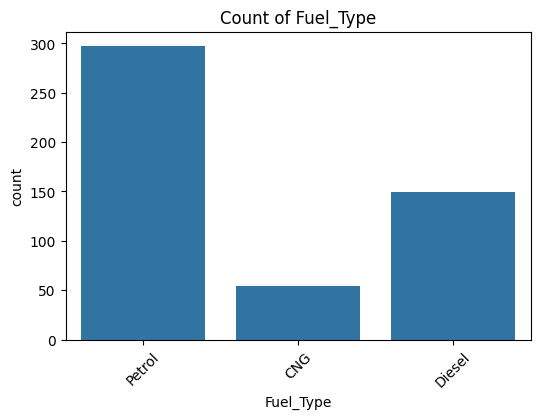

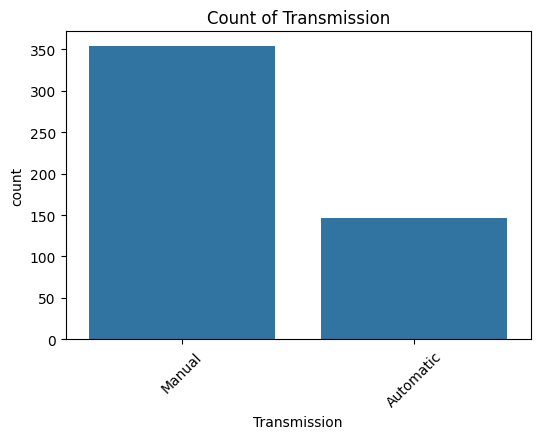

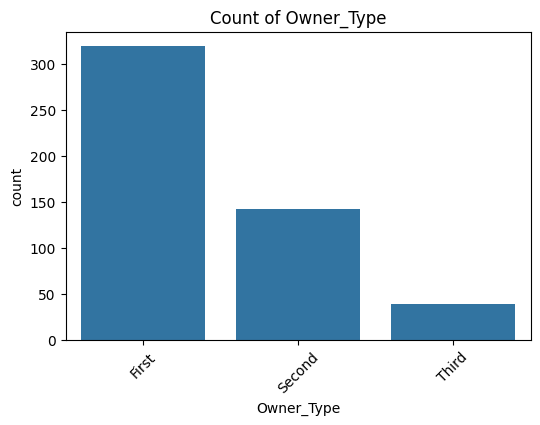

In [15]:
categorical_cols = ["Brand","Fuel_Type","Transmission","Owner_Type"]

for col in categorical_cols:
    plt.figure(figsize = (6,4))
    sns.countplot(x = data[col])
    plt.title(f"Count of {col}")
    plt.xticks(rotation = 45)
    plt.show()

### Bivariate Analysis
Numerical Features Vs Target

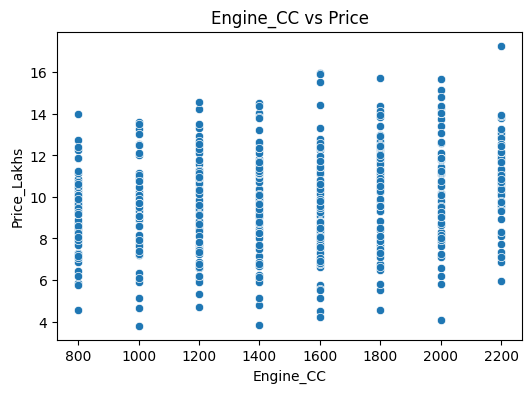

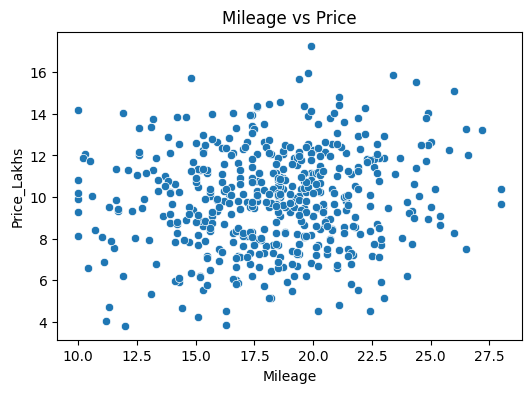

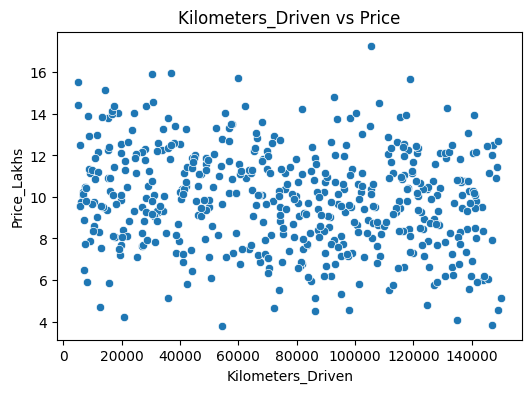

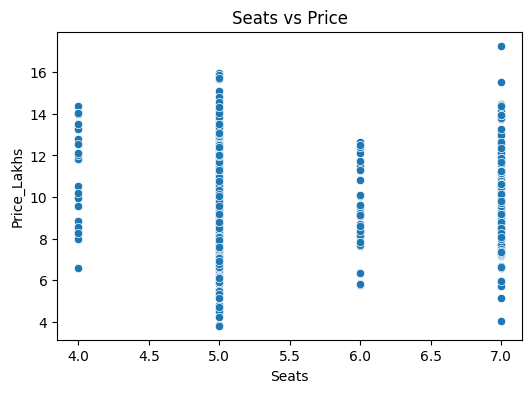

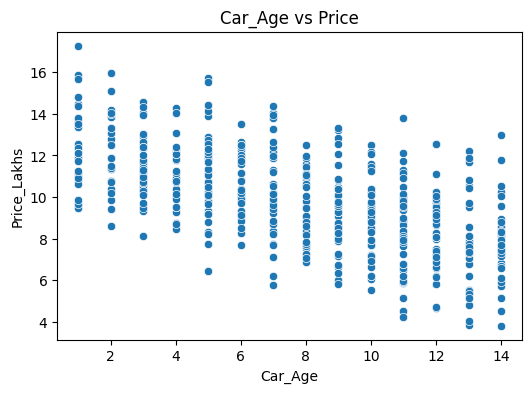

In [16]:
for col in numerical_cols[:-1]:
    plt.figure(figsize = (6,4))
    sns.scatterplot(x = data[col], y = data["Price_Lakhs"])
    plt.title(f"{col} vs Price")
    plt.show()

Categorical features Vs Target

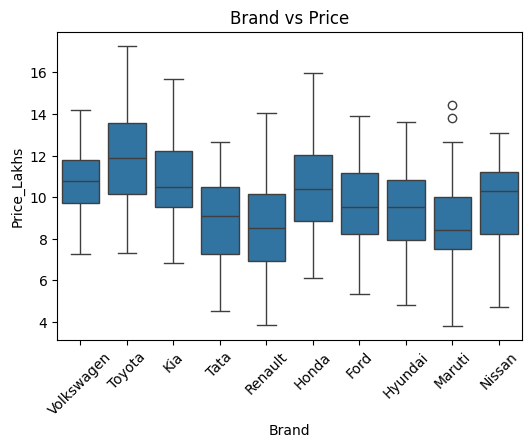

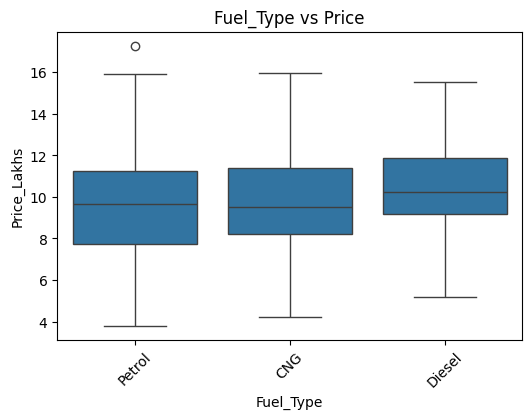

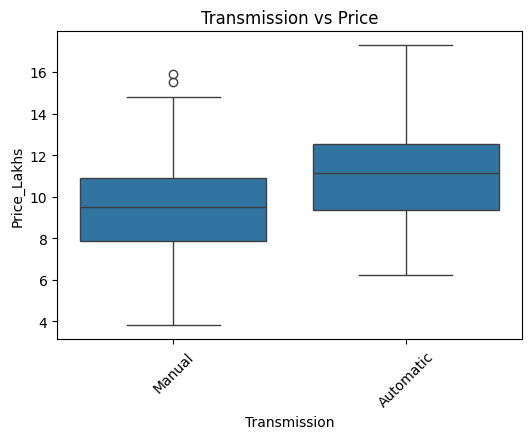

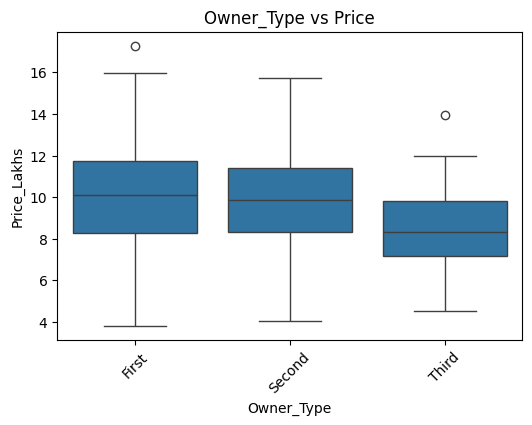

In [17]:
for col in categorical_cols:
    plt.figure(figsize = (6,4))
    sns.boxplot(x = data[col], y = data["Price_Lakhs"])
    plt.title(f"{col} vs Price")
    plt.xticks(rotation = 45)
    plt.show()

Correlation Between Numerical Variables

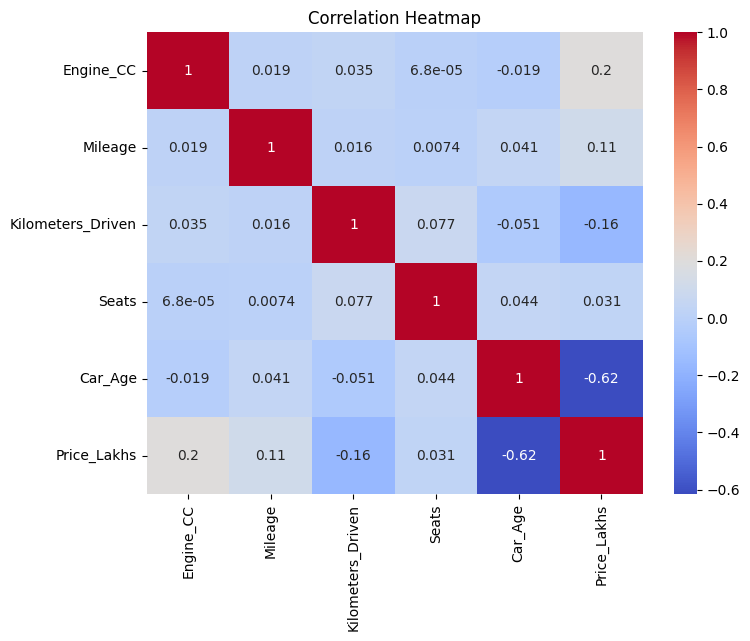

In [18]:
plt.figure(figsize = (8,6))
sns.heatmap(data[numerical_cols].corr(),annot = True,cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Encoding Categorical Variables
   #### One-hot encoding

In [19]:
categorical_cols = ["Brand","Fuel_Type","Transmission","Owner_Type"]
data[categorical_cols].head()

,Brand,Fuel_Type,Transmission,Owner_Type
0,Volkswagen,Petrol,Manual,First
1,Toyota,CNG,Manual,First
2,Kia,Petrol,Manual,First
3,Tata,Diesel,Manual,Second
4,Volkswagen,Petrol,Manual,Second


In [20]:
data = pd.get_dummies(data,columns = categorical_cols,drop_first = True)

In [21]:
data

,Year,Engine_CC,Mileage,Kilometers_Driven,Seats,Price_Lakhs,Car_Age,Brand_Honda,Brand_Hyundai,Brand_Kia,...,Brand_Nissan,Brand_Renault,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Second,Owner_Type_Third
0,2015,1600.0,14.2,59330,5.0,8.26,11,False,False,False,...,False,False,False,False,True,False,True,True,False,False
1,2015,1800.0,19.2,56707,7.0,11.73,11,False,False,False,...,False,False,False,True,False,False,False,True,False,False
2,2017,1400.0,27.2,23689,5.0,13.24,9,False,False,True,...,False,False,False,False,False,False,True,True,False,False
3,2021,1800.0,11.7,34084,5.0,9.31,5,False,False,False,...,False,False,True,False,False,True,False,True,True,False
4,2021,1400.0,16.2,45387,7.0,9.81,5,False,False,False,...,False,False,False,False,True,False,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2017,1400.0,21.3,104165,7.0,8.28,9,False,False,False,...,False,False,False,False,False,False,True,False,True,False
496,2016,800.0,21.5,60863,7.0,11.25,10,False,False,False,...,False,False,False,False,True,False,True,True,False,False
497,2014,800.0,11.0,87569,7.0,8.06,12,False,False,False,...,False,False,False,False,True,True,False,True,False,False
498,2020,1600.0,24.8,21351,6.0,11.72,6,False,False,False,...,True,False,False,False,False,False,True,True,False,False


### Define Features and Target variables

In [22]:
x = data.drop("Price_Lakhs",axis = 1)
y = data["Price_Lakhs"]

In [23]:
x.head()

,Year,Engine_CC,Mileage,Kilometers_Driven,Seats,Car_Age,Brand_Honda,Brand_Hyundai,Brand_Kia,Brand_Maruti,Brand_Nissan,Brand_Renault,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Second,Owner_Type_Third
0,2015,1600.0,14.2,59330,5.0,11,False,False,False,False,False,False,False,False,True,False,True,True,False,False
1,2015,1800.0,19.2,56707,7.0,11,False,False,False,False,False,False,False,True,False,False,False,True,False,False
2,2017,1400.0,27.2,23689,5.0,9,False,False,True,False,False,False,False,False,False,False,True,True,False,False
3,2021,1800.0,11.7,34084,5.0,5,False,False,False,False,False,False,True,False,False,True,False,True,True,False
4,2021,1400.0,16.2,45387,7.0,5,False,False,False,False,False,False,False,False,True,False,True,True,True,False


In [24]:
y.head()

0     8.26
1    11.73
2    13.24
3     9.31
4     9.81
Name: Price_Lakhs, dtype: float64

### Train-test Split

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [27]:
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)

X_train: (400, 20)
X_test: (100, 20)


In [28]:
print("Y_train:",Y_train.shape)
print("Y_test:",Y_test.shape)

Y_train: (400,)
Y_test: (100,)


### Model Building
#### Decision Tree Regression
Trained a Decision Tree Regressor to predict car prices based on the given features

In [29]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state = 42)

In [30]:
dt_model.fit(X_train,Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [31]:
y_pred_dt = dt_model.predict(X_test)

### Model Evaluation for Decision Tree Regression
Evaluated the Decision Tree model using MAE,MSE, and R2 score

In [32]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mae_dt = mean_absolute_error(Y_test,y_pred_dt)
mse_dt = mean_squared_error(Y_test,y_pred_dt)
r2_dt = r2_score(Y_test,y_pred_dt)

print("MAE :",mae_dt)
print("MSE :",mse_dt)
print("R2 score :",r2_dt)

MAE : 1.5416999999999996
MSE : 3.493501
R2 score : 0.0625645752885019


#### Random Forest Regression
Trained a Random Forest Regressor to improve prediction performance using multiple decision trees

In [34]:
from sklearn.ensemble import RandomForestRegressor

In [35]:
rf_model = RandomForestRegressor(n_estimators = 100,random_state = 42)
rf_model.fit(X_train,Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [36]:
y_pred_rf = rf_model.predict(X_test)

### Model Evaluation Random Forest Regression
Evaluated the Random Forest model using the metrics MAE,MSE,R2 score

In [38]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mae_rf = mean_absolute_error(Y_test,y_pred_rf)
mse_rf = mean_squared_error(Y_test,y_pred_rf)
r2_score_rf= r2_score(Y_test,y_pred_rf)

print("MAE :",mae_rf)
print("MSE :",mse_rf)
print("R2 score :",r2_score_rf)

MAE : 1.0181039999999992
MSE : 1.5777675087999983
R2 score : 0.5766266691471024


### Model Comaparison

"Random Forest" performed better than Decision Tree based on MAE,MSE, and R2 score

### Save the best model 
Saved the Random Forest model for future predictions and Streamlit deployment


In [39]:
import joblib

In [40]:
joblib.dump(rf_model,"Model.pkl")

['Model.pkl']

In [41]:
feature_columns = x.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']